### The University of Melbourne, School of Computing and Information Systems
# COMP90086 Computer Vision, 2025 Semester 2 Assignment 3

**Student Name:**    `YU LUO`

**Student ID:**     `1528667`

This iPython notebook is a template which you should use for your Assignment 3 submission. This file should be submitted at the **Assignment 3: Code** link on the LMS.

In addition to this file, you should submit a written report explaining your results at the **Assignment 3: Report** link on the LMS. Please see the assignment specification for details on what must be included in the report for each question.

*Adding proper comments to your code is MANDATORY.*

# Code Template

## 0. Building and Using Autoencoders (Default Setup)

Necessary imports

In [1]:
# Imports
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow version: ", tf.__version__)

TensorFlow version:  2.19.0


### 0.1 Load the MNIST training and test data into tensors

In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# load the train and test images into tensors and rescale pixel values
train_images = train_images.astype(float) / 255 #scale the pixel values to be 0-1
test_images = test_images.astype(float) / 255

# tranform the input to be a 4D input with batch_shape + (rows, cols, channels) if data_format='channels_last'(default)

#transform training data
train_images = np.expand_dims(train_images, axis = -1)

#transform testing data
test_images = np.expand_dims(test_images, axis = -1)

#check the shape of each tensor
print("train_images shape:", train_images.shape)
print("test_images shape:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train_images shape: (60000, 28, 28, 1)
test_images shape: (10000, 28, 28, 1)


### 0.2 Set the number of channels in the latent representation (Default Code)

In [3]:
embedding_size = 16

## 1. Define and train the Autoencoder


### 1.1 (Default) Autoencoder Model

Define the default encoder and decoder models and combine to make the whole autoencoder model

Note: In part 3 of the Assignment, you should add your own design(s) for your autoencoders

In [4]:
# Encoder
encoder = keras.Sequential(
    [
        layers.Input((28,28,1)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(embedding_size)
    ]
)

# Decoder
decoder = keras.Sequential(
    [
        layers.Input((embedding_size,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(28*28*1),
        layers.Reshape((28,28,1))
    ]
)

# Autoencoder is encoder followed by decoder
autoencoder = keras.Sequential([encoder,decoder])

### 1.2 Compile and train the autoencoder

In [5]:
# Configure the model
autoencoder.compile(optimizer='adam',
            loss=tf.keras.losses.MeanSquaredError,
           #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #use SparseCategoricalCrossentropy because labels are integers. If the labels are one-hot representation, please use CategoricalCrossentropy loss.
           metrics=['mse'])

# Start training
# we use train_images as both the input and the target value for our autoencoder (no labels!)
history_autoencoder = autoencoder.fit(train_images, train_images, epochs=200, batch_size=100, validation_split=0.2)

Epoch 1/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0496 - mse: 0.0496 - val_loss: 0.0246 - val_mse: 0.0246
Epoch 2/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0239 - mse: 0.0239 - val_loss: 0.0223 - val_mse: 0.0223
Epoch 3/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0218 - mse: 0.0218 - val_loss: 0.0210 - val_mse: 0.0210
Epoch 4/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0208 - mse: 0.0208 - val_loss: 0.0202 - val_mse: 0.0202
Epoch 5/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0200 - mse: 0.0200 - val_loss: 0.0196 - val_mse: 0.0196
Epoch 6/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0194 - mse: 0.0194 - val_loss: 0.0191 - val_mse: 0.0191
Epoch 7/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0189 - mse: 0.0189 - val_loss: 0.0187 - val_mse: 0.0187
Epoch 8/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0186 - mse: 0.0186 - val_loss: 0.0185 - val_mse: 0.0185
Epoch 9/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms

### 1.3 Display the training and validation loss curves

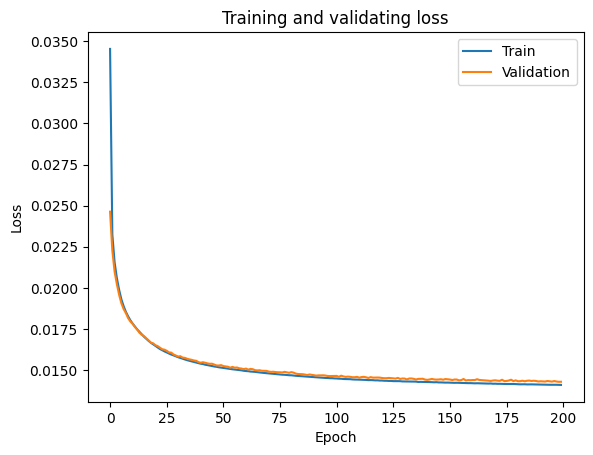

In [6]:
plt.plot(history_autoencoder.history['loss'], label='Train')
plt.plot(history_autoencoder.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

### 1.4 Qualitative Evaluation of autoencoder performance

The above graphs show the loss (mean squared error) on the training and validation splits of the training set. We can also observe how the algorithm reconstructs a random sample from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


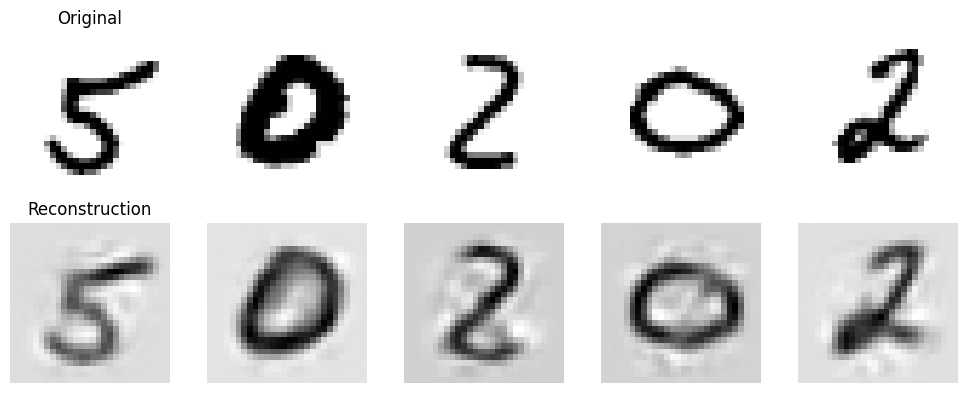

In [7]:
# Show 5 random samples and their reconstructions side by side
num_samples = 5
sample_ids = np.random.choice(test_images.shape[0], size=num_samples, replace=False)
digits = test_images[sample_ids]

# expand dimensions for prediction if needed
predict_digits = autoencoder.predict(digits)

fig, axes = plt.subplots(nrows=2, ncols=num_samples, figsize=(num_samples * 2, 4))

for i in range(num_samples):
    # Original
    axes[0, i].imshow(digits[i].squeeze(), cmap="binary")
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original")
    # Reconstruction
    axes[1, i].imshow(predict_digits[i].squeeze(), cmap="binary")
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstruction")

plt.tight_layout()
plt.show()

## 2. Building a Classifier from the Autoencoder representations

### 2.1 Convert the training images into latent embeddings

In [8]:
# transform the training set into latent embeddings
train_embeddings = encoder.predict(train_images)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


### 2.2 (Default) Define the classifier
This is a two layer classifier that first projects onto hidden dimensions with relu and then onto the classification space with softmax

In [9]:
classifier = keras.Sequential(
    [
        layers.Input((embedding_size,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

### 2.3 Compile and train the classifier
This uses the converted embeddings as input and the labels as target.
Note that the validation_split is 0.999
This means that only 0.001 of the training set is used to train the classifier (60 examples in total)

In [10]:
classifier.compile(optimizer='adam',
           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
           metrics=['accuracy'])
history_classifier = classifier.fit(train_embeddings, train_labels, epochs=800, batch_size=100, validation_split=0.999)

Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1000 - loss: 2.4292 - val_accuracy: 0.1032 - val_loss: 2.4928
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1000 - loss: 2.4205 - val_accuracy: 0.1045 - val_loss: 2.4870
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1167 - loss: 2.4119 - val_accuracy: 0.1060 - val_loss: 2.4814
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1167 - loss: 2.4034 - val_accuracy: 0.1074 - val_loss: 2.4758
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1333 - loss: 2.3951 - val_accuracy: 0.1088 - val_loss: 2.4703
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step - accuracy: 0.1500 - loss: 2.3869 - val_accuracy: 0.1104 - val_loss: 2.4649
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step - accuracy: 0.1667 - loss: 2.3787 - val_accuracy: 0.1119 - val_loss: 2.4595
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step - accuracy: 0.1667 - loss: 2.3706 - val_accuracy: 0.1136 - val_loss: 2.4542

### 2.4 Display the training and validation result

#### 2.4.1 Training and validation accuracy

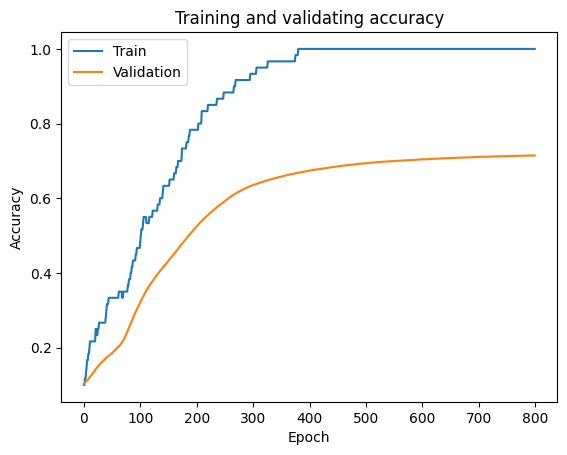

In [13]:
plt.plot(history_classifier.history['accuracy'], label='Train')
plt.plot(history_classifier.history['val_accuracy'], label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Training and validating accuracy')
plt.legend()
plt.show()

#### 2.4.2 Training and valdiation loss

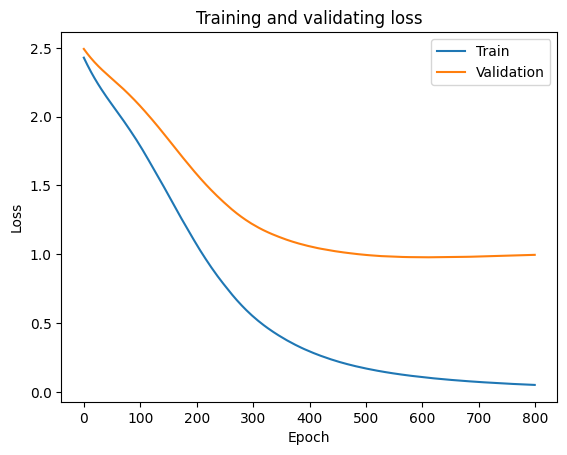

In [14]:
plt.plot(history_classifier.history['loss'], label='Train')
plt.plot(history_classifier.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

## 3. Build and Train a conventional baseline classfier


### 3.1 (Default) Create the baseline MLP Classifier from Worksheet 4

In [15]:
# Create the baseline classifier
baseline_classifier = keras.Sequential(
    [
        layers.Input((28,28,1)),               # Tell Keras the shape of the input array (a single-channel 28×28 image)
        layers.Flatten(),                      # Unravel/flatten the input array
        layers.Dense(16, activation='relu'),   # Add a fully-connected layer with 16 units and ReLU activation function as the hidden layer
        layers.Dense(10, activation='softmax') # Add a fully-connected layer with a softmax activation function
    ]
)

### 3.2 Compile and train the classifier
Again we use a 0.999 validation split so that training only sees 60 examples

In [16]:
baseline_classifier.compile(optimizer='adam',
           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
           metrics=['accuracy'])
history_baseline_classifier = baseline_classifier.fit(train_images, train_labels, epochs=800, batch_size=100, validation_split=0.999)

Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1333 - loss: 2.4094 - val_accuracy: 0.1434 - val_loss: 2.3489
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1333 - loss: 2.3450 - val_accuracy: 0.1577 - val_loss: 2.3144
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1333 - loss: 2.2860 - val_accuracy: 0.1728 - val_loss: 2.2848
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2000 - loss: 2.2320 - val_accuracy: 0.1867 - val_loss: 2.2597
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2000 - loss: 2.1835 - val_accuracy: 0.2013 - val_loss: 2.2373
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2833 - loss: 2.1378 - val_accuracy: 0.2131 - val_loss: 2.2167
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3500 - loss: 2.0951 - val_accuracy: 0.2235 - val_loss: 2.1972
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4167 - loss: 2.0547 - val_accuracy: 0.2331 - val_loss: 2.1785
Epoch 9/

### 3.3 Display the training and validation result

#### 3.3.1 Training and validation accuracy

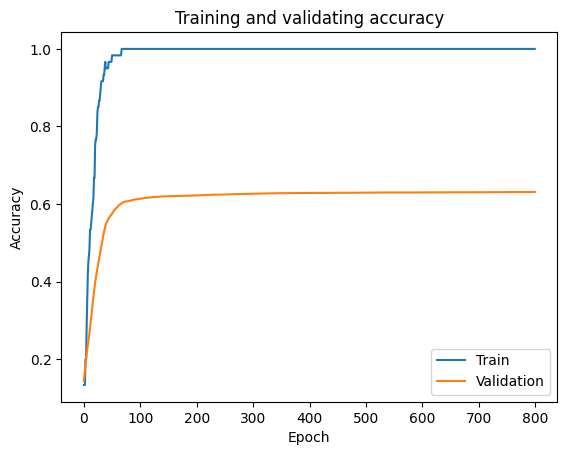

In [17]:
plt.plot(history_baseline_classifier.history['accuracy'], label='Train')
plt.plot(history_baseline_classifier.history['val_accuracy'], label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Training and validating accuracy')
plt.legend()
plt.show()

#### 3.3.2 Training and validation loss

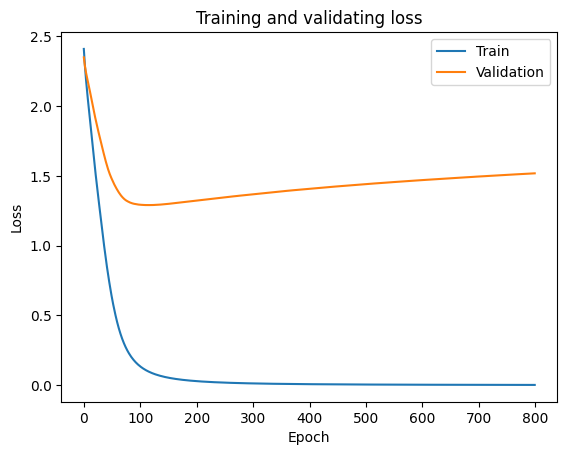

In [18]:
plt.plot(history_baseline_classifier.history['loss'], label='Train')
plt.plot(history_baseline_classifier.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

In [19]:
# Print the final results for the autoencoder-based classifier
print("="*50)
print("Autoencoder-Based Classifier: Final Performance")
print("="*50)
print(f"Final Training Accuracy:   {history_classifier.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_classifier.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss:       {history_classifier.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history_classifier.history['val_loss'][-1]:.4f}")
print("="*50)
# Print the final results for the autoencoder-based classifier
print("="*50)
print("Baseline MLP Classifier: Final Performance")
print("="*50)
print(f"Final Training Accuracy:   {history_baseline_classifier.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_baseline_classifier.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss:       {history_baseline_classifier.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history_baseline_classifier.history['val_loss'][-1]:.4f}")
print("="*50)



Autoencoder-Based Classifier: Final Performance
Final Training Accuracy:   1.0000
Final Validation Accuracy: 0.7146
Final Training Loss:       0.0504
Final Validation Loss:     0.9959
Baseline MLP Classifier: Final Performance
Final Training Accuracy:   1.0000
Final Validation Accuracy: 0.6310
Final Training Loss:       0.0019
Final Validation Loss:     1.5180


# My Experiment

# Part 2: Experiment Code

---

This section contains the code to automate the experiments for Part 2.


### 2.1 Coarse Granularity Search for Optimal Embedding Size

In [ ]:
def experiment_embedding_size_for_autoencoder(embedding_sizes):
    # Dictionary to store the experiment results
    experiment_results = {
        "embedding_size": [],
        "ae_reconstruction_loss": [],
        "clf_training_accuracy": [],
        "clf_training_loss": [],
        "clf_validation_accuracy": [],
        "clf_validation_loss": [],
        "training_time": [],
    }

    # Dictionary to store trained autoencoders for test reconstruction
    experiment_embedding_autoencoders = {}

    for embedding_size in embedding_sizes:
        print(f"--- Training with embedding_size = {embedding_size} ---")

        # Record the start time for training the autoencoder
        import time
        start_time = time.time()

        # === 1. Define and Train the Autoencoder ===
        encoder = keras.Sequential(
            [
                layers.Input((28, 28, 1)),
                layers.Flatten(),
                layers.Dense(128, activation='relu'),
                layers.Dense(embedding_size)
            ],
            name=f"encoder_{embedding_size}"
        )

        decoder = keras.Sequential(
            [
                layers.Input((embedding_size,)),
                layers.Dense(128, activation='relu'),
                layers.Dense(28 * 28 * 1),
                layers.Reshape((28, 28, 1))
            ],
            name=f"decoder_{embedding_size}"
        )
        # Same setup as the original code
        autoencoder = keras.Sequential([encoder, decoder], name=f"autoencoder_{embedding_size}")

        # Tain to minimize the mean squared error between the original and reconstructed images
        autoencoder.compile(
            optimizer='adam',
            loss=tf.keras.losses.MeanSquaredError(),
            metrics=['mse']
        )
        # Train the autoencoder
        # Use 200 epochs and a batch size of 100 for training
        history_autoencoder = autoencoder.fit(
            train_images,
            train_images,
            epochs=200,
            batch_size=100,
            validation_split=0.2,
            verbose=0
        )

        # === 2. Use the trained autoencoder to build and train the classifier ===

        # Transform the training set into latent embeddings of given embedding size
        train_embeddings = encoder.predict(train_images, verbose=0)

        # Define the default classifier which has a hidden layer with 16 units
        # and a softmax output layer with 10 units
        classifier = keras.Sequential(
            [
                layers.Input((embedding_size,)),
                layers.Dense(16, activation='relu'),
                layers.Dense(10, activation='softmax')
            ],
            name=f"classifier_{embedding_size}"
        )

        # Compile the classifier with the same loss function and optimizer as the original code
        classifier.compile(
            optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=['accuracy']
        )

        # Train the classifier for 500 epochs with a batch size of 100 and a validation split of 0.999
        history_classifier = classifier.fit(
            train_embeddings,
            train_labels,
            epochs=500,
            batch_size=100,
            validation_split=0.999,
            verbose=0
        )

        # Record the end time for training the classifier
        end_time = time.time()
        elapsed_time = end_time - start_time


        # Record results
        experiment_results["embedding_size"].append(embedding_size)
        experiment_results["ae_reconstruction_loss"].append(history_autoencoder.history['val_loss'][-1])
        experiment_results["clf_training_accuracy"].append(history_classifier.history['accuracy'][-1])
        experiment_results["clf_training_loss"].append(history_classifier.history['loss'][-1])
        experiment_results["clf_validation_accuracy"].append(history_classifier.history['val_accuracy'][-1])
        experiment_results["clf_validation_loss"].append(history_classifier.history['val_loss'][-1])
        experiment_results["training_time"].append(elapsed_time)


        print(f"Embedding_size {embedding_size}: Final Classification val_accuracy = {history_classifier.history['val_accuracy'][-1]:.4f}")
        # Save the trained autoencoder for test reconstruction
        experiment_embedding_autoencoders[embedding_size] = autoencoder

    # return the experiment results and the trained autoencoders
    return experiment_results, experiment_embedding_autoencoders


Initial coarse search uses exponentially increasing embedding sizes to efficiently explore the parameter space from 2 to 128 dimensions.

In [ ]:

# List of embedding sizes to experiment with
first_round_embedding_sizes = [2, 4, 8, 16, 32, 64, 128]

first_round_experiment_results, first_round_experiment_embedding_autoencoders = experiment_embedding_size_for_autoencoder(first_round_embedding_sizes)

--- Training with embedding_size = 2 ---
Embedding_size 2: Final Classification val_accuracy = 0.5530
--- Training with embedding_size = 4 ---
Embedding_size 4: Final Classification val_accuracy = 0.7185
--- Training with embedding_size = 8 ---
Embedding_size 8: Final Classification val_accuracy = 0.7383
--- Training with embedding_size = 16 ---
Embedding_size 16: Final Classification val_accuracy = 0.6930
--- Training with embedding_size = 32 ---
Embedding_size 32: Final Classification val_accuracy = 0.6267
--- Training with embedding_size = 64 ---
Embedding_size 64: Final Classification val_accuracy = 0.5673
--- Training with embedding_size = 128 ---
Embedding_size 128: Final Classification val_accuracy = 0.5741


In [ ]:
# Display the experiment results as a DataFrame
df_results = pd.DataFrame(first_round_experiment_results)
display(df_results)

# Explanation: What does the reconstruction_loss represent?
# The "ae_reconstruction_loss" column in the results DataFrame shows the final validation loss of the autoencoder for each embedding size.
# This reconstruction loss measures how well the autoencoder is able to reconstruct the original input images from their compressed (encoded) representations.
# Typically, it is the mean squared error (MSE) or binary cross-entropy between the original and reconstructed images.
# Lower reconstruction loss means the autoencoder is better at preserving information about the input during compression and decompression.


,embedding_size,ae_reconstruction_loss,clf_training_accuracy,clf_training_loss,clf_validation_accuracy,clf_validation_loss,training_time
0,2,0.040724,0.716667,0.974901,0.553020,1.273359,202.051333
1,4,0.030818,0.883333,0.493826,0.718502,0.889539,203.199828
2,8,0.021553,0.950000,0.376040,0.738255,0.864927,208.647316
3,16,0.014392,1.000000,0.171043,0.693043,1.039049,221.840081
4,32,0.010103,1.000000,0.122766,0.626710,1.150941,227.415122
5,64,0.007861,1.000000,0.080856,0.567284,1.418958,270.339087
6,128,0.006488,1.000000,0.035783,0.574107,1.340392,302.128339


### 2.2 Finer Granularity Search for Optimal Embedding Size

After identifying the optimal range for embedding size, I now focus on a finer search within the 4-16 range, using increments of 2, to pinpoint the best embedding size.

In [ ]:
# Second round of experiments for embedding sizes [6, 10, 12, 14]
second_round_embedding_sizes = [6, 10, 12, 14]

second_round_experiment_results, second_round_experiment_embedding_autoencoders = experiment_embedding_size_for_autoencoder(second_round_embedding_sizes)

--- Training with embedding_size = 6 ---
Embedding_size 6: Final Classification val_accuracy = 0.7471
--- Training with embedding_size = 10 ---
Embedding_size 10: Final Classification val_accuracy = 0.7770
--- Training with embedding_size = 12 ---
Embedding_size 12: Final Classification val_accuracy = 0.6946
--- Training with embedding_size = 14 ---
Embedding_size 14: Final Classification val_accuracy = 0.7092


In [ ]:
# Display the experiment results as a DataFrame
df_results_second_round = pd.DataFrame(second_round_experiment_results)
display(df_results_second_round)


,embedding_size,ae_reconstruction_loss,clf_training_accuracy,clf_training_loss,clf_validation_accuracy,clf_validation_loss,training_time
0,6,0.024924,0.933333,0.388853,0.747097,0.801358,227.795889
1,10,0.019217,0.966667,0.262314,0.777044,0.703438,270.279416
2,12,0.016793,0.983333,0.197664,0.694578,0.918151,267.635416
3,14,0.015584,1.000000,0.181354,0.709243,0.940493,287.896684


### 2.3 Search Result Display

In [ ]:
# Combine first and second round results into a single DataFrame
df_results_combined = pd.concat([df_results, df_results_second_round], ignore_index=True)


In [ ]:

# Display only the embedding size, reconstruction loss, and validation accuracy (in %), sorted by embedding size
df_display = df_results_combined[["embedding_size", "ae_reconstruction_loss", "clf_validation_accuracy"]].copy()
df_display["clf_validation_accuracy"] = (df_display["clf_validation_accuracy"] * 100).round(2)
df_display = df_display.rename(columns={"clf_validation_accuracy": "clf_validation_accuracy (%)"})
df_display = df_display.sort_values("embedding_size").reset_index(drop=True)
display(df_display)

,embedding_size,ae_reconstruction_loss,clf_validation_accuracy (%)
0,2,0.040724,55.30
1,4,0.030818,71.85
2,6,0.024924,74.71
3,8,0.021553,73.83
4,10,0.019217,77.70
5,12,0.016793,69.46
6,14,0.015584,70.92
7,16,0.014392,69.30
8,32,0.010103,62.67
9,64,0.007861,56.73


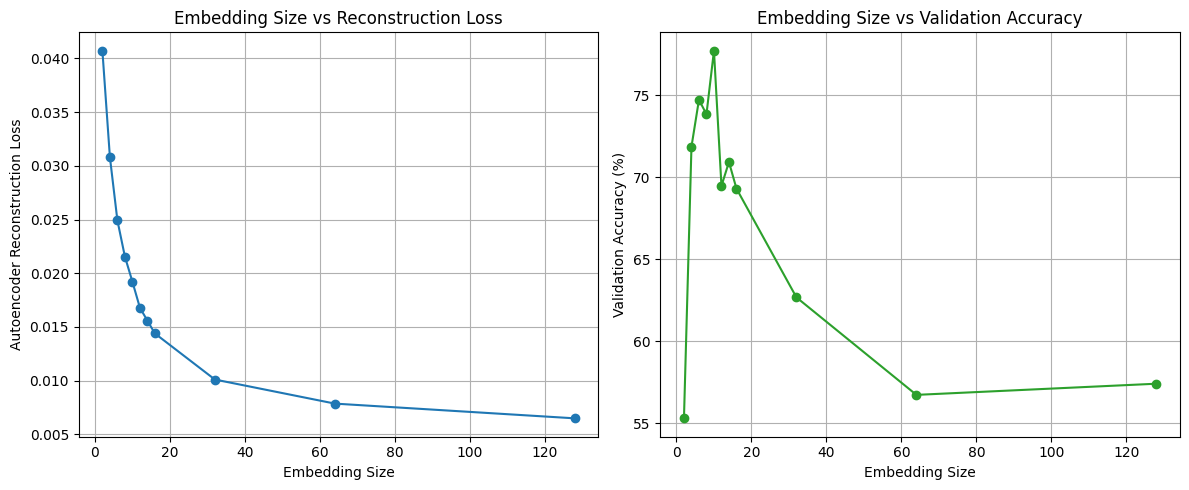

In [ ]:
# Plot embedding size vs reconstruction loss and embedding size vs validation accuracy

plt.figure(figsize=(12, 5))

# Plot 1: Embedding size vs Reconstruction Loss
plt.subplot(1, 2, 1)
plt.plot(df_display["embedding_size"], df_display["ae_reconstruction_loss"], marker='o', color='tab:blue')
plt.xlabel("Embedding Size")
plt.ylabel("Autoencoder Reconstruction Loss")
plt.title("Embedding Size vs Reconstruction Loss")
plt.grid(True)

# Plot 2: Embedding size vs Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(df_display["embedding_size"], df_display["clf_validation_accuracy (%)"], marker='o', color='tab:green')
plt.xlabel("Embedding Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Embedding Size vs Validation Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Combine the autoencoders from both rounds into a single dictionary
combined_experiment_embedding_autoencoders = {}
combined_experiment_embedding_autoencoders.update(first_round_experiment_embedding_autoencoders)
combined_experiment_embedding_autoencoders.update(second_round_experiment_embedding_autoencoders)


# Sort the autoencoders by embedding size
combined_experiment_embedding_autoencoders = dict(sorted(combined_experiment_embedding_autoencoders.items()))

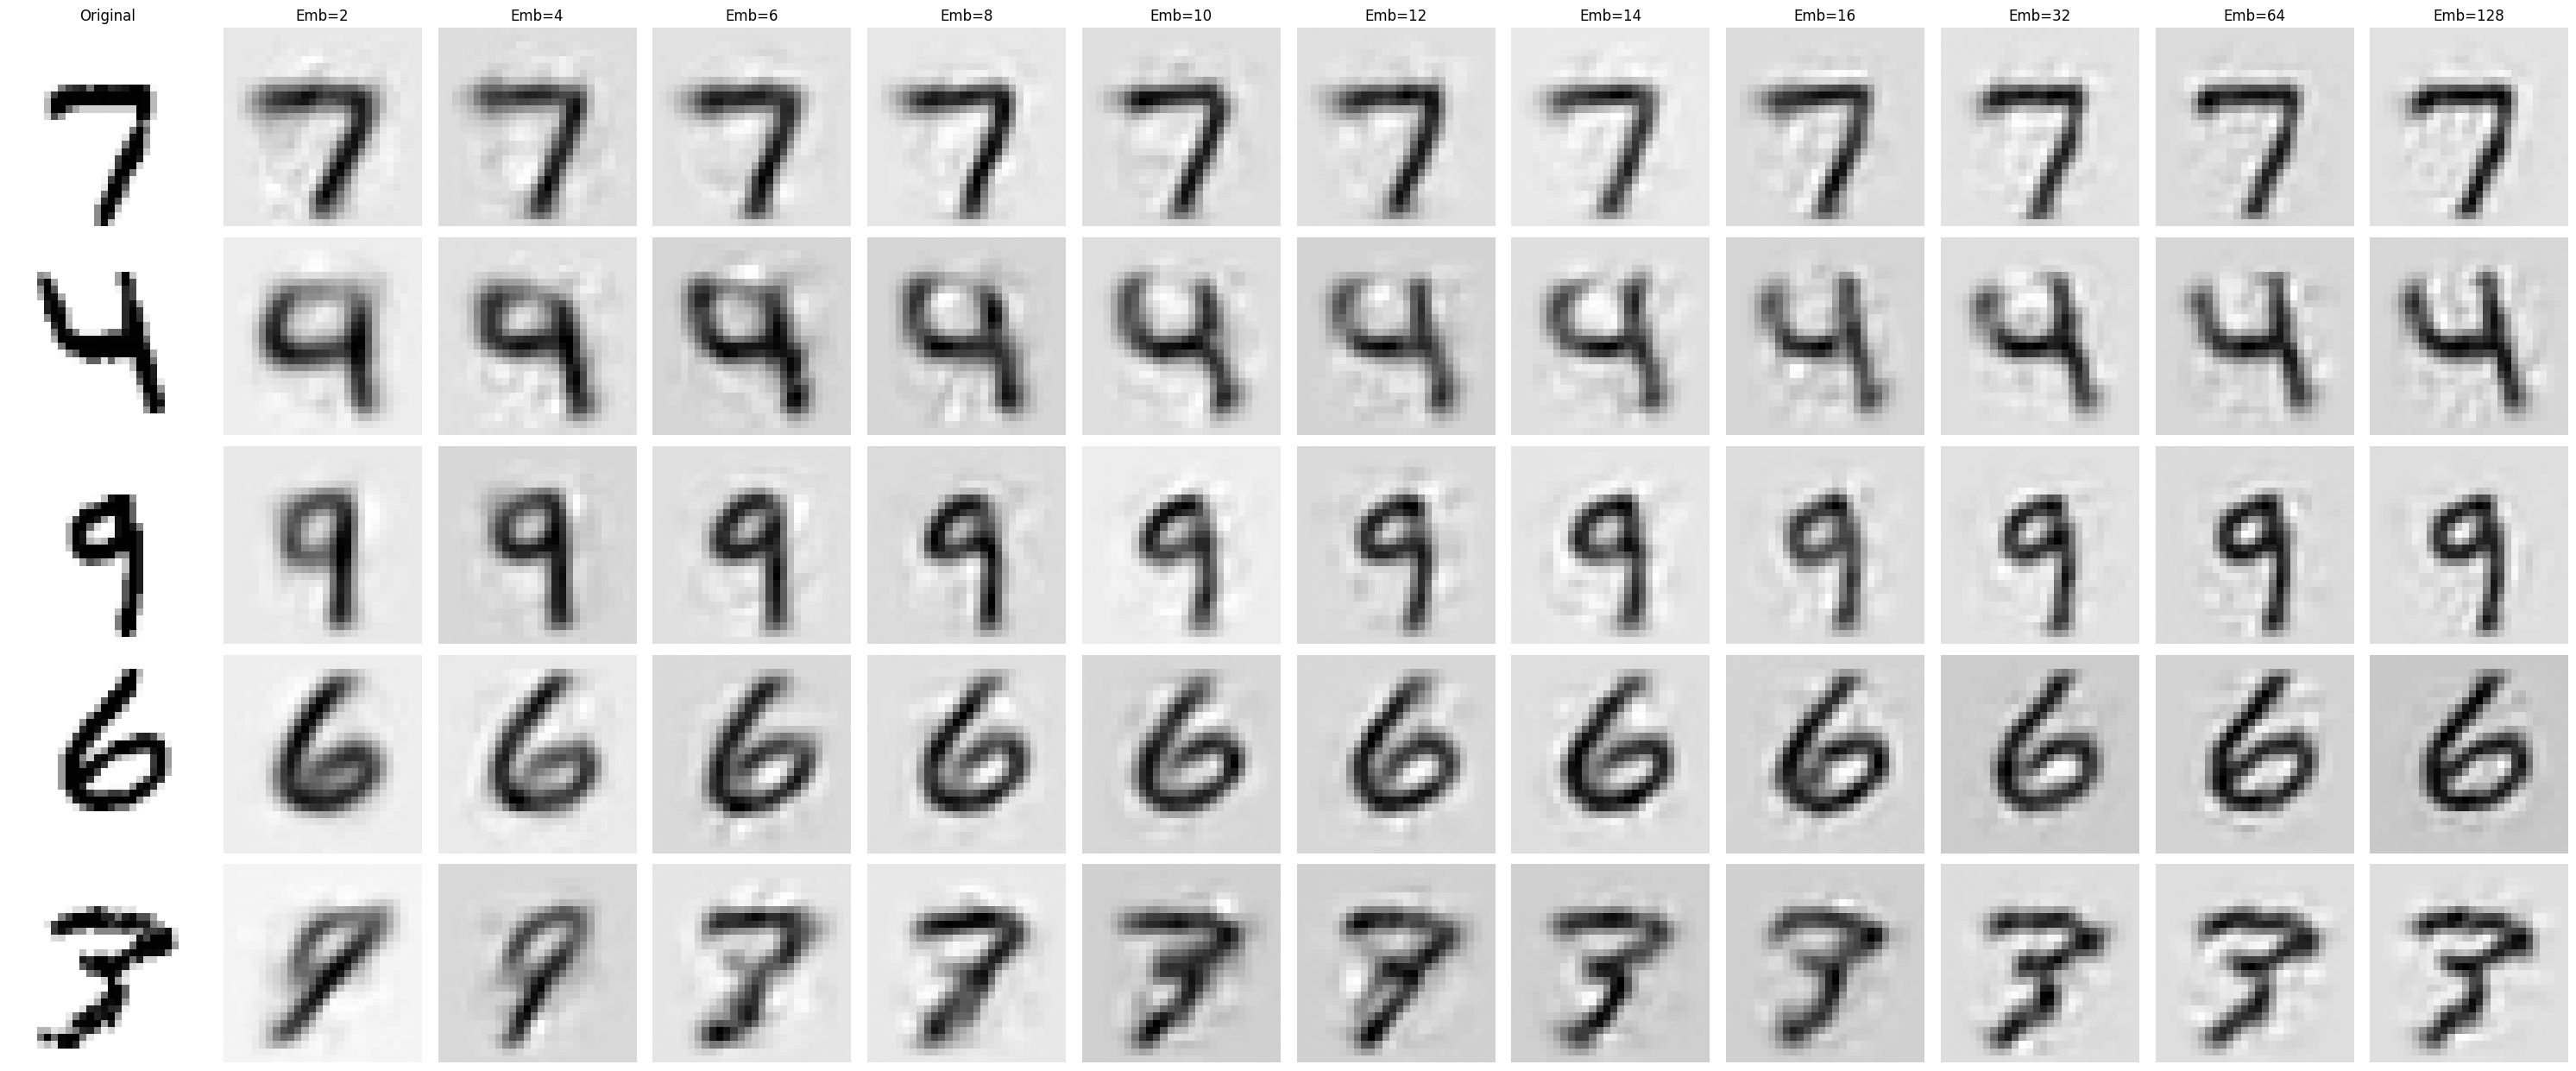

In [ ]:
# Show num_samples random samples and their reconstructions for each embedding size (autoencoder)
num_samples = 5
sample_ids = np.random.choice(test_images.shape[0], size=num_samples, replace=False)
embedding_sizes = list(combined_experiment_embedding_autoencoders.keys())
num_autoencoders = len(embedding_sizes)

fig, axes = plt.subplots(
    nrows=num_samples,
    ncols=num_autoencoders + 1,
    figsize=(2.5 * (num_autoencoders + 1), 2.5 * num_samples)
)

# If only one sample, axes will be 1D, so make it 2D for consistency
if num_samples == 1:
    axes = axes[np.newaxis, :]

for row_idx, sample_id in enumerate(sample_ids):
    digit = test_images[sample_id]
    # Show the original image in the first column
    axes[row_idx, 0].imshow(digit.squeeze(), cmap="binary")
    axes[row_idx, 0].axis('off')
    if row_idx == 0:
        axes[row_idx, 0].set_title("Original")
    # Show reconstructions for each embedding size
    for col_idx, (emb_size, autoencoder) in enumerate(combined_experiment_embedding_autoencoders.items(), start=1):
        predict_digit = autoencoder.predict(digit[np.newaxis, ...], verbose=0)[0]
        axes[row_idx, col_idx].imshow(predict_digit.squeeze(), cmap="binary")
        axes[row_idx, col_idx].axis('off')
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(f"Emb={emb_size}")

plt.tight_layout()
plt.show()


# Part 3: Autoencoder and Classifier Design

---

This section is for the code and experiments for Part 3.


In [ ]:
# --- Experiment Configuration ---
# Embedding size is fixed for all autoencoders to ensure comparability
embedding_size_p3 = 10

### 3.1 Autoencoder Architecture Comparison

This experiment compares different autoencoder architectures to determine which one generates the most effective features for classifying MNIST digits.

- Dense Autoencoder (Baseline): This model flattens the 28x28 image into a single vector, which unfortunately discards all spatial information about the digit's structure. I also evaluated a deeper dense version to see if additional layers could compensate for this loss by extracting better patterns from the flattened input.

- Convolutional Autoencoder (CNN): Since our data is image-based, a convolutional autoencoder is particularly well-suited. CNNs use convolutional filters and pooling layers to extract and preserve spatial features from the 2D structure of the digits—such as the loops in an "8" or the vertical stroke in a "1"—which dense networks may overlook. This architecture is designed to capture local patterns and spatial hierarchies, making it more effective for image reconstruction and feature extraction. In this experiment, I evaluate two different kernel sizes for the convolutional layers to investigate how the receptive field size influences the quality of learned embeddings.

The core hypothesis is that the CNN encoder will learn more informative features (embeddings) for the classifier, resulting in higher classification accuracy. To ensure a fair comparison, I kept both the embedding size and the final classifier architecture identical across all experiments. This setup isolates the impact of the encoder's feature quality on overall performance.

In [ ]:
# Part 3, Experiment 1: Compare different autoencoder architectures using a fixed classifier.
# The goal is to see which autoencoder produces the best features for downstream classification.
# All autoencoders use the same embedding size and the same classifier for a fair comparison.

print(f"--- Part 3: Autoencoder Architecture Comparison (embedding_size = {embedding_size_p3}) ---")

# --- Define Autoencoder Architectures ---

def build_original_dense_autoencoder(embedding_size):
    """
    Baseline autoencoder: Flattens the image and uses two dense layers for encoding and decoding.
    This model ignores spatial structure in the image.
    """
    encoder = keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(embedding_size)
    ], name="original_encoder")
    decoder = keras.Sequential([
        layers.Input((embedding_size,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(28 * 28 * 1),
        layers.Reshape((28, 28, 1))
    ], name="original_decoder")
    autoencoder = keras.Sequential([encoder, decoder], name="original_autoencoder")
    return autoencoder, encoder

def build_deeper_dense_autoencoder(embedding_size):
    """
    Deeper dense autoencoder: Adds an extra dense layer (256 units) in both encoder and decoder.
    Tests if increased depth helps learn better features from the flattened image.
    """
    encoder = keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(embedding_size)
    ], name="deeper_dense_encoder")
    decoder = keras.Sequential([
        layers.Input((embedding_size,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(28 * 28 * 1),
        layers.Reshape((28, 28, 1))
    ], name="deeper_dense_decoder")
    autoencoder = keras.Sequential([encoder, decoder], name="deeper_dense_autoencoder")
    return autoencoder, encoder


def build_convolutional_autoencoder(embedding_size, kernel_size=3):
    """
    Convolutional autoencoder: Uses convolutional and pooling layers to preserve spatial information.
    The encoder compresses the image to a dense embedding; the decoder reconstructs the image.
    This convolutional autoencoder has default 3x3 convolutional layers (16 and 32 filters) and two max-pooling layers.
    """
    encoder = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2), padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2), padding="same"),
        layers.Flatten(),
        layers.Dense(embedding_size, activation="relu")
    ], name="convolutional_encoder")
    decoder = keras.Sequential([
        layers.Input(shape=(embedding_size,)),
        layers.Dense(7 * 7 * 32, activation="relu"),
        layers.Reshape((7, 7, 32)),
        layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"),
        layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same"),
        layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")
    ], name="convolutional_decoder")
    autoencoder = keras.Sequential([encoder, decoder], name="convolutional_autoencoder")
    return autoencoder, encoder

# List of autoencoder architectures to evaluate.
autoencoder_architectures = [
    ("Convolutional_5x5", lambda embedding_size: build_convolutional_autoencoder(embedding_size, kernel_size=5)),
    ("Convolutional_3x3", build_convolutional_autoencoder),
    ("Original Dense", build_original_dense_autoencoder),
    ("Deeper Dense", build_deeper_dense_autoencoder),
]

# Dictionary to store the final validation accuracy for each architecture.
part3_ex1_results = {}

# For plotting: store histories, reconstructions, and autoencoders for each architecture
autoencoder_histories = {}
autoencoder_models = {}

# --- Main Experiment Loop ---
# For each autoencoder architecture:
#   1. Train the autoencoder to reconstruct images.
#   2. Use the encoder to generate embeddings for the training set.
#   3. Train a fixed classifier on these embeddings.
#   4. Record the final validation accuracy.
for arch_name, build_fn in autoencoder_architectures:
    print(f"\n--- Training Autoencoder Architecture: {arch_name} ---")
    # Build the autoencoder and its encoder part
    autoencoder, encoder = build_fn(embedding_size_p3)
    # Use mean squared error (MSE) loss for image reconstruction, as in previous code.
    autoencoder.compile(optimizer='adam', loss=tf.keras.losses.MeanSquaredError(), metrics=['mse'])
    # Train the autoencoder to reconstruct its input images
    history = autoencoder.fit(
        train_images, train_images,
        epochs=200,
        batch_size=100,
        validation_split=0.2,
        verbose=1
    )

    # Save the final autoencoder loss for this architecture
    final_ae_loss = history.history['val_loss'][-1]
    print(f"[{arch_name}] Final Autoencoder Validation Loss: {final_ae_loss:.4f}")

    # Save the history and autoencoder model for this architecture for plotting later
    autoencoder_histories[arch_name] = history
    autoencoder_models[arch_name] = autoencoder

    # Generate embeddings for the training images using the trained encoder
    train_embeddings = encoder.predict(train_images, verbose=0)
    # Define a simple classifier (same for all autoencoders) to ensure fair comparison
    classifier = keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name="shared_classifier")

    classifier.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the classifier on the embeddings; use almost all data for validation to match original setup
    # This will be trained for 500 epochs with a batch size of 100
    clf_history = classifier.fit(
        train_embeddings, train_labels,
        epochs=500,
        batch_size=100,
        validation_split=0.999,  # nearly all data for validation, as in original code
        verbose=1
    )
    # Save the final validation accuracy for this architecture
    final_val_acc = clf_history.history['val_accuracy'][-1]


    part3_ex1_results[arch_name] = {
        'ae_history': history.history,
        'clf_history': clf_history.history
    }
    print(f"[{arch_name}] Final Classification Validation Accuracy: {final_val_acc:.4f}")


--- Part 3: Autoencoder Architecture Comparison (embedding_size = 10) ---

--- Training Autoencoder Architecture: Convolutional_5x5 ---
Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - loss: 0.1743 - mse: 0.1743 - val_loss: 0.0736 - val_mse: 0.0736
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0717 - mse: 0.0717 - val_loss: 0.0685 - val_mse: 0.0685
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 0.0683 - mse: 0.0683 - val_loss: 0.0638 - val_mse: 0.0638
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 0.0628 - mse: 0.0628 - val_loss: 0.0546 - val_mse: 0.0546
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0509 - mse: 0.0509 - val_loss: 0.0418 - val_mse: 0.0418
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - loss: 0.0394 - mse: 0.0394 - val_loss: 0.0342 - val_mse: 0.0342
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0333 - mse: 0.0333 - val_loss: 0.0315 - val_mse: 0.0315
Epoch 8/200
48/48 ━━━━━━━━━━━━━

In [ ]:

# Collect results into a list of dicts for tabular display
table_rows = []
for arch_name, results in part3_ex1_results.items():
    ae_loss = results['ae_final_loss'] if 'ae_final_loss' in results else results['ae_history']['val_loss'][-1] if 'val_loss' in results['ae_history'] else results['ae_history']['loss'][-1]
    clf_val_acc = results['clf_final_val_acc'] if 'clf_final_val_acc' in results else results['clf_history']['val_accuracy'][-1] if 'val_accuracy' in results['clf_history'] else results['clf_history']['accuracy'][-1]
    table_rows.append({
        "Architecture": arch_name,
        "AE Val Loss": ae_loss,
        "Classifier Val Accuracy": clf_val_acc
    })

results_df = pd.DataFrame(table_rows)
# Format columns for readability
results_df["AE Val Loss"] = results_df["AE Val Loss"].map(lambda x: f"{x:.5f}")
results_df["Classifier Val Accuracy"] = results_df["Classifier Val Accuracy"].map(lambda x: f"{x:.4f}")

print("Final Results Summary:")
display(results_df)


Final Results Summary:


,Architecture,AE Val Loss,Classifier Val Accuracy
0,Convolutional_5x5,0.01837,0.6571
1,Convolutional_3x3,0.02358,0.5462
2,Original Dense,0.01955,0.6957
3,Deeper Dense,0.01584,0.7765


Learning curves for various autoencoder architectures, each paired with the same classifier (simple MLP with 16 units) and an embedding size of 10.

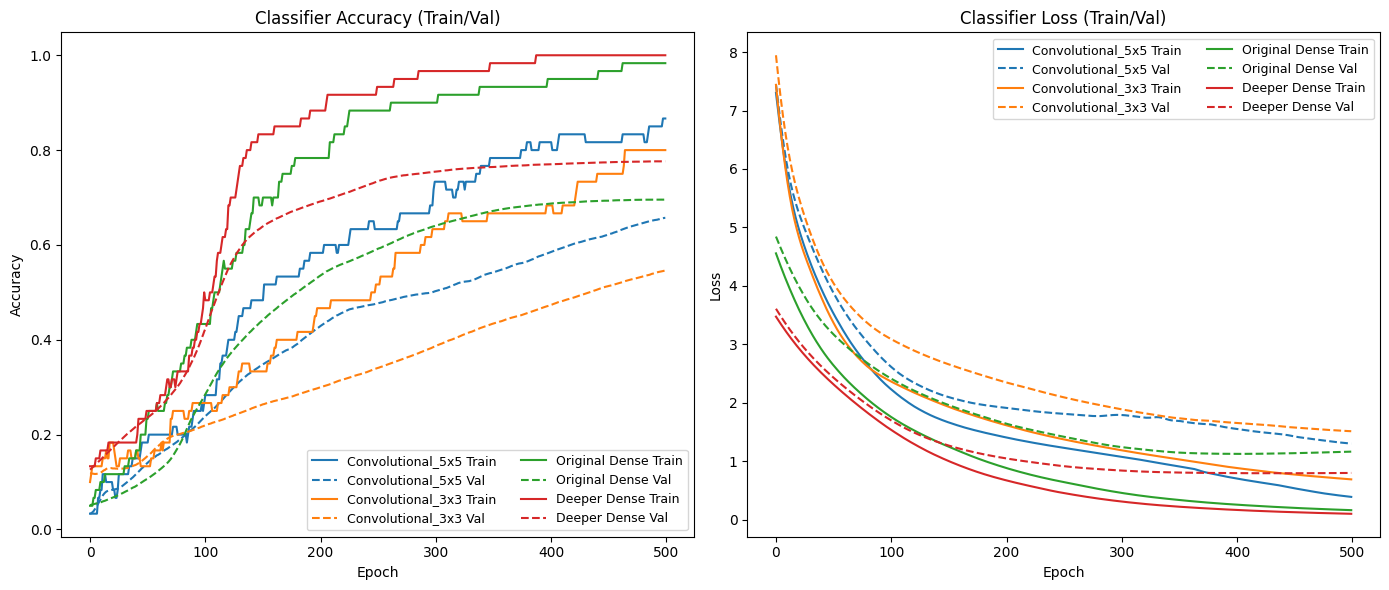

In [ ]:

# Overlay learning curves (accuracy and loss) for all architectures, each with one color
color_cycle = plt.cm.tab10.colors  # 10 distinct colors
arch_names = list(part3_ex1_results.keys())
color_map = {arch: color_cycle[i % len(color_cycle)] for i, arch in enumerate(arch_names)}

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].set_title("Classifier Accuracy (Train/Val)")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[1].set_title("Classifier Loss (Train/Val)")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")

for i, (arch_name, results) in enumerate(part3_ex1_results.items()):
    clf_history = results['clf_history']
    color = color_map[arch_name]
    # Accuracy: train solid, val dashed
    axs[0].plot(clf_history['accuracy'], label=f"{arch_name} Train", color=color, linestyle='-')
    if 'val_accuracy' in clf_history:
        axs[0].plot(clf_history['val_accuracy'], label=f"{arch_name} Val", color=color, linestyle='--')
    # Loss: train solid, val dashed
    axs[1].plot(clf_history['loss'], label=f"{arch_name} Train", color=color, linestyle='-')
    if 'val_loss' in clf_history:
        axs[1].plot(clf_history['val_loss'], label=f"{arch_name} Val", color=color, linestyle='--')

# Legends
axs[0].legend(loc='best', fontsize=9, ncol=2)
axs[1].legend(loc='best', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

Reconstruction samples from the test set

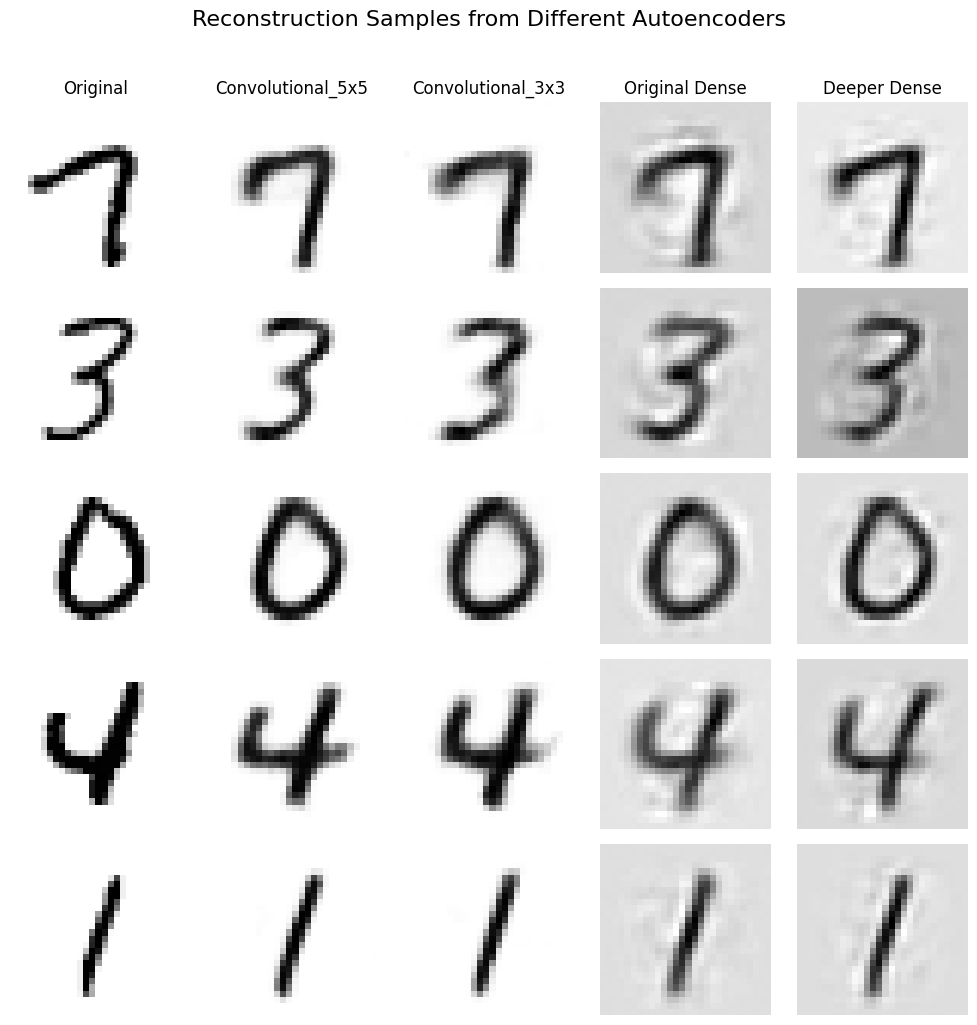

In [ ]:
# Show some reconstruction samples using different autoencoders

import numpy as np

n_samples = 5
sample_idxs = np.random.choice(len(test_images), n_samples, replace=False)
sample_imgs = test_images[sample_idxs]

ae_names = ["Original"] + list(autoencoder_models.keys())
n_autoencoders = len(autoencoder_models)

fig, axs = plt.subplots(n_samples, n_autoencoders + 1, figsize=(2*(n_autoencoders+1), 2*n_samples))
fig.suptitle("Reconstruction Samples from Different Autoencoders", fontsize=16, y=1.02)

for row in range(n_samples):
    # Show original image in first column
    axs[row, 0].imshow(sample_imgs[row].squeeze(), cmap='binary')
    if row == 0:
        axs[row, 0].set_title("Original")
    axs[row, 0].axis('off')
    # Show reconstructions from each autoencoder
    for col, (arch_name, model) in enumerate(autoencoder_models.items(), start=1):
        # If model is (autoencoder, encoder) tuple, use autoencoder
        if isinstance(model, (tuple, list)):
            autoencoder = model[0]
        else:
            autoencoder = model
        recons = autoencoder.predict(np.expand_dims(sample_imgs[row], axis=0), verbose=0)
        axs[row, col].imshow(recons[0].squeeze(), cmap='binary')
        if row == 0:
            axs[row, col].set_title(arch_name)
        axs[row, col].axis('off')

plt.tight_layout()
plt.show()

### 3.2 Classifier Architecture Comparison

In this experiment, we investigate how the choice of classifier architecture affects performance when trained on embeddings produced by a convolutional autoencoder. The autoencoder is first trained to compress input images into a 10-dimensional latent space. We then use the same encoder to generate embeddings for the training images, which serve as input features for the classifiers.

**Motivation**:
Our aim is to explore how the representational power of different classifiers interacts with the information preserved in the autoencoder's embeddings. If the embeddings are highly informative and linearly separable, a simple classifier should perform well. Conversely, if the embeddings encode more complex or non-linear relationships, deeper or wider classifiers may be required to fully leverage this information.

The classifier architectures evaluated in this experiment include:

- **Baseline (1 Hidden Layer, 16 units):** A single dense hidden layer with 16 units, followed by a softmax output. This matches the architecture used in the previous experiment, providing a fair baseline for comparison.
- **Medium (1 Hidden Layer, 32 units):** A single dense hidden layer with 32 units, increasing model capacity relative to the baseline. This may help capture more complex patterns in the embeddings, especially if the data is not linearly separable.
- **Deep (2 Hidden Layers, 64 + 32 units):** Two dense hidden layers with 64 and 32 units, respectively. Stacking layers enables the classifier to learn more abstract and hierarchical features from the embeddings, potentially capturing intricate relationships that a single layer might miss. For example, MNIST digits may require distinguishing between subtle shape components, such as vertical strokes or loops, which deeper models can represent.
- **Wide (1 Hidden Layer, 128 units):** A single dense hidden layer with 128 units, greatly increasing the number of parameters in a single transformation. A wide layer can model more complex decision boundaries in one step, which may be beneficial if the embeddings are not linearly separable but do not require deep hierarchical processing. Comparing wide versus deep architectures helps reveal whether the information in the embeddings is best exploited through depth (multiple transformations) or width (more parallel features).

For each architecture, we train the classifier on the embeddings and report the final validation accuracy, using the same training/validation split as in the previous setup to ensure consistency and comparability.


In [ ]:
# --- Part 3, Experiment 2: Different Classifier Architectures using CNN Autoencoder ---

# Get the trained encoder from the convolutional autoencoder from last experiment
cnn_encoder = autoencoder_models["Convolutional_5x5"].layers[0]

# Generate embeddings for training set using embedding size 10
cnn_train_embeddings = cnn_encoder.predict(train_images, verbose=0)

# Define different classifier architectures to compare
classifier_architectures = [
    ("1 Hidden Layer (16 units, Baseline)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])),
    ("1 Hidden Layer (32 units, Medium)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])),
    ("2 Hidden Layers (64 + 32 units, Deep)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])),
    ("1 Wide Hidden Layer (128 units, Wide)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]))
]

part3_ex2_results = {}

for clf_name, clf_model in classifier_architectures:
    clf_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = clf_model.fit(
        cnn_train_embeddings, train_labels,
        epochs=500,
        batch_size=100,
        validation_split=0.999,  # almost all data for validation
        verbose=1
    )
    final_val_acc = history.history['val_accuracy'][-1]
    part3_ex2_results[clf_name] = {
        "history": history.history
    }
    print(f"Final Validation Accuracy for '{clf_name}': {final_val_acc:.4f}")

# --- Print Summary ---
print("\n--- Part 3: Classifier Architecture Comparison Results (using CNN Autoencoder, embedding size 10) ---")
for clf_name, result in part3_ex2_results.items():
    final_val_acc = result["history"]['val_accuracy'][-1]
    final_val_loss = result["history"]['val_loss'][-1]
    print(f"{clf_name}: val_acc={final_val_acc:.4f}, val_loss={final_val_loss:.4f}")


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.1000 - loss: 28.2538 - val_accuracy: 0.0974 - val_loss: 28.8393
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 27.8115 - val_accuracy: 0.0974 - val_loss: 28.4101
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1000 - loss: 27.3718 - val_accuracy: 0.0974 - val_loss: 27.9837
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1000 - loss: 26.9351 - val_accuracy: 0.0974 - val_loss: 27.5600
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 26.5017 - val_accuracy: 0.0974 - val_loss: 27.1392
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1000 - loss: 26.0708 - val_accuracy: 0.0974 - val_loss: 26.7212
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 25.6446 - val_accuracy: 0.0974 - val_loss: 26.3061
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1000 - loss: 25.2222 - val_accuracy: 0.

In [ ]:
# Prepare results for table display
ex_2_clf_table = []
for clf_name, result in part3_ex2_results.items():
    final_val_acc = result["history"]['val_accuracy'][-1]
    final_val_loss = result["history"]['val_loss'][-1]
    ex_2_clf_table.append({
        "Architecture": clf_name,
        "Final Validation Accuracy": f"{final_val_acc:.4f}",
        "Final Validation Loss": f"{final_val_loss:.5f}"
    })

df_clf_results = pd.DataFrame(ex_2_clf_table)
display(df_clf_results)

,Architecture,Final Validation Accuracy,Final Validation Loss
0,"1 Hidden Layer (16 units, Baseline)",0.5877,1.34003
1,"1 Hidden Layer (32 units, Medium)",0.7004,1.08637
2,"2 Hidden Layers (64 + 32 units, Deep)",0.7047,1.10777
3,"1 Wide Hidden Layer (128 units, Wide)",0.7459,1.17797


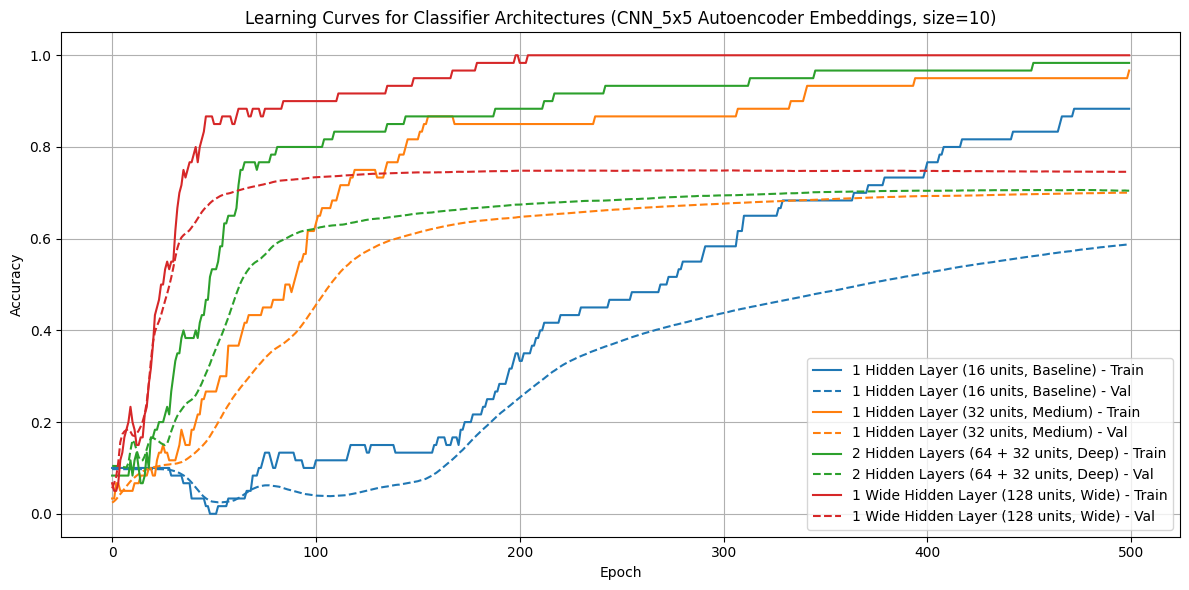

In [ ]:
# Assign a unique color to each classifier architecture for consistent coloring
import itertools
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
clf_names = list(part3_ex2_results.keys())
color_map = {name: color_cycle[i % len(color_cycle)] for i, name in enumerate(clf_names)}

plt.figure(figsize=(12, 6))
for clf_name, result in part3_ex2_results.items():
    history = result["history"]
    color = color_map[clf_name]
    plt.plot(history['accuracy'], label=f"{clf_name} - Train", color=color)
    plt.plot(history['val_accuracy'], linestyle='--', label=f"{clf_name} - Val", color=color)

plt.title("Learning Curves for Classifier Architectures (CNN_5x5 Autoencoder Embeddings, size=10)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.3 Regularisation Experiment


In this experiment, we explore the impact of different regularisation techniques on the performance of classifiers trained on embeddings produced by a CNN autoencoder (with embedding size 10). Our baseline is a wide multilayer perceptron (MLP) classifier (one hidden layer of 128 units) with no regularisation, serving as a reference for comparison. We then introduce three common regularisation strategies: L2 weight decay (with a penalty coefficient of 0.01), L1 weight penalty (also with a coefficient of 0.01), and Dropout (with a dropout rate of 0.5 applied after the hidden layer). All classifiers share the same architecture—an input layer matching the embedding size, a single hidden layer of 128 ReLU units, and a softmax output layer for 10 classes—ensuring that differences in performance can be attributed to the regularisation method rather than model capacity. We train each model for 500 epochs using the Adam optimiser and a large batch size, with nearly all data reserved for validation to highlight generalisation effects. By comparing validation accuracies across these settings, we aim to assess which regularisation approaches are most effective at mitigating overfitting and improving generalisation in the context of limited training data and learned feature representations.

In [ ]:
# Experiment: Testing Regularisation in Classifier Architectures

regularisation_architectures = [
    ("L2 Regularisation (0.01)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(10, activation='softmax')
    ])),
    ("L1 Regularisation (0.01)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l1(0.01)),
        layers.Dense(10, activation='softmax')
    ])),
    ("Dropout (0.5)", keras.Sequential([
        layers.Input(shape=(embedding_size_p3,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])),
]

part3_reg_results = {}

for clf_name, clf_model in regularisation_architectures:
    clf_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = clf_model.fit(
        cnn_train_embeddings, train_labels,
        epochs=500,
        batch_size=100,
        validation_split=0.999,  # almost all data for validation
        verbose=1
    )
    final_val_acc = history.history['val_accuracy'][-1]
    part3_reg_results[clf_name] = history.history
    print(f"Final Validation Accuracy for '{clf_name}': {final_val_acc:.4f}")

# --- Print Summary ---
print("\n--- Part 3: Regularisation Experiment Results (using CNN Autoencoder) ---")
for clf_name, history in part3_reg_results.items():
    final_val_acc = history['val_accuracy'][-1]
    print(f"{clf_name}: {final_val_acc:.4f}")


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.0167 - loss: 8.8860 - val_accuracy: 0.0128 - val_loss: 8.4491
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0167 - loss: 8.0853 - val_accuracy: 0.0208 - val_loss: 7.7477
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0500 - loss: 7.3912 - val_accuracy: 0.0321 - val_loss: 7.1471
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0833 - loss: 6.8024 - val_accuracy: 0.0424 - val_loss: 6.6271
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 6.2862 - val_accuracy: 0.0499 - val_loss: 6.1578
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1167 - loss: 5.8054 - val_accuracy: 0.0551 - val_loss: 5.7201
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1333 - loss: 5.3466 - val_accuracy: 0.0594 - val_loss: 5.3055
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1333 - loss: 4.9073 - val_accuracy: 0.0670 - val_loss

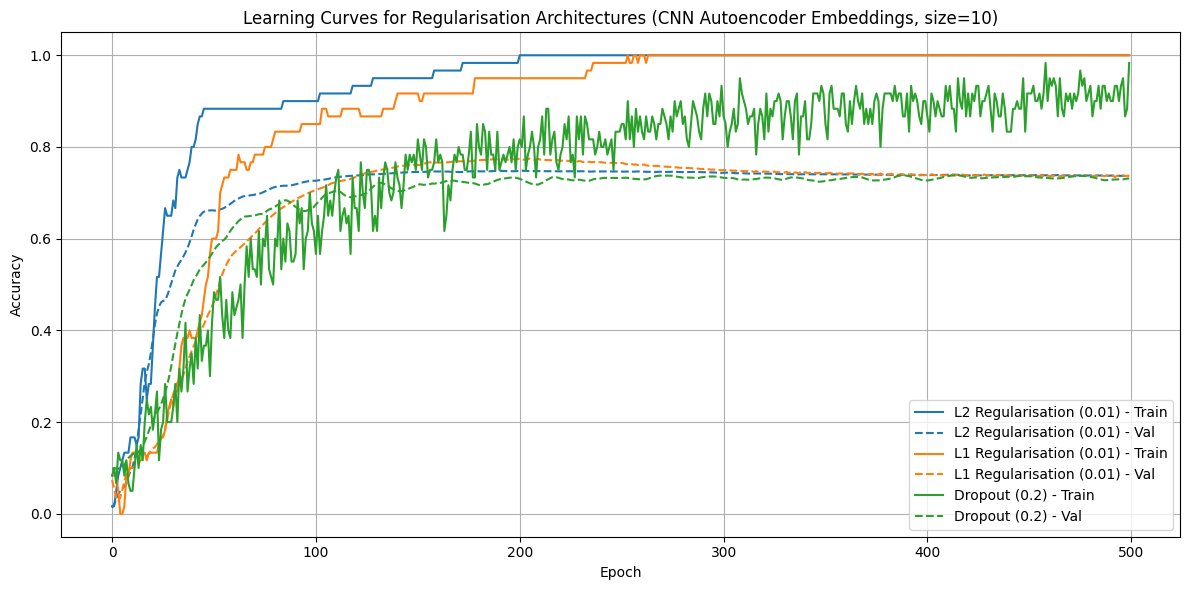

In [ ]:
# Assign a unique color to each regularisation architecture for consistent coloring
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
reg_names = list(part3_reg_results.keys())
color_map = {name: color_cycle[i % len(color_cycle)] for i, name in enumerate(reg_names)}

plt.figure(figsize=(12, 6))
for reg_name, history in part3_reg_results.items():
    color = color_map[reg_name]
    plt.plot(history['accuracy'], label=f"{reg_name} - Train", color=color)
    plt.plot(history['val_accuracy'], linestyle='--', label=f"{reg_name} - Val", color=color)

plt.title("Learning Curves for Regularisation Architectures (CNN Autoencoder Embeddings, size=10)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# --- Print Summary in Table ---
print("\n--- Part 3: Regularisation Experiment Results (using CNN Autoencoder) ---")
ex3_reg_summary = []
for clf_name, history in part3_reg_results.items():
    final_val_acc = history['val_accuracy'][-1]
    final_val_loss = history['val_loss'][-1]
    ex3_reg_summary.append({
        'Architecture': clf_name,
        'Final Validation Accuracy': final_val_acc,
        'Final Validation Loss': final_val_loss
    })

summary_df = pd.DataFrame(ex3_reg_summary)
summary_df['Final Validation Accuracy'] = summary_df['Final Validation Accuracy'].map("{:.4f}".format)
summary_df['Final Validation Loss'] = summary_df['Final Validation Loss'].map("{:.5f}".format)
display(summary_df)


--- Part 3: Regularisation Experiment Results (using CNN Autoencoder) ---


,Architecture,Final Validation Accuracy,Final Validation Loss
0,L2 Regularisation (0.01),0.7376,1.30603
1,L1 Regularisation (0.01),0.7363,1.69819
2,Dropout (0.2),0.7312,0.97798


### 3.4 Final Model

In this section, I have integrated the key insights from previous experiments to design a more effective pipeline. The setup follows the provided code structure, but with improvements based on earlier results. Specifically, I use a deeper, denser autoencoder to generate embeddings, followed by a wide MLP classifier. To reduce overfitting, I apply L2 regularisation to the MLP and include dropout, which helps prevent the model from relying too heavily on specific neurons and encourages better generalisation to unseen data.

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy: 0.1000 - loss: 2.5322 - val_accuracy: 0.2070 - val_loss: 2.4660
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.1833 - loss: 2.5363 - val_accuracy: 0.2170 - val_loss: 2.4494
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.1667 - loss: 2.5004 - val_accuracy: 0.2270 - val_loss: 2.4329
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.1833 - loss: 2.4321 - val_accuracy: 0.2379 - val_loss: 2.4167
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.2167 - loss: 2.4395 - val_accuracy: 0.2517 - val_loss: 2.4006
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.0667 - loss: 2.5084 - val_accuracy: 0.2681 - val_loss: 2.3847
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.1167 - loss: 2.4421 - val_accuracy: 0.2885 - val_loss: 2.3690
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.1833 - loss: 2.4175 - val_accuracy: 0.3130 - v

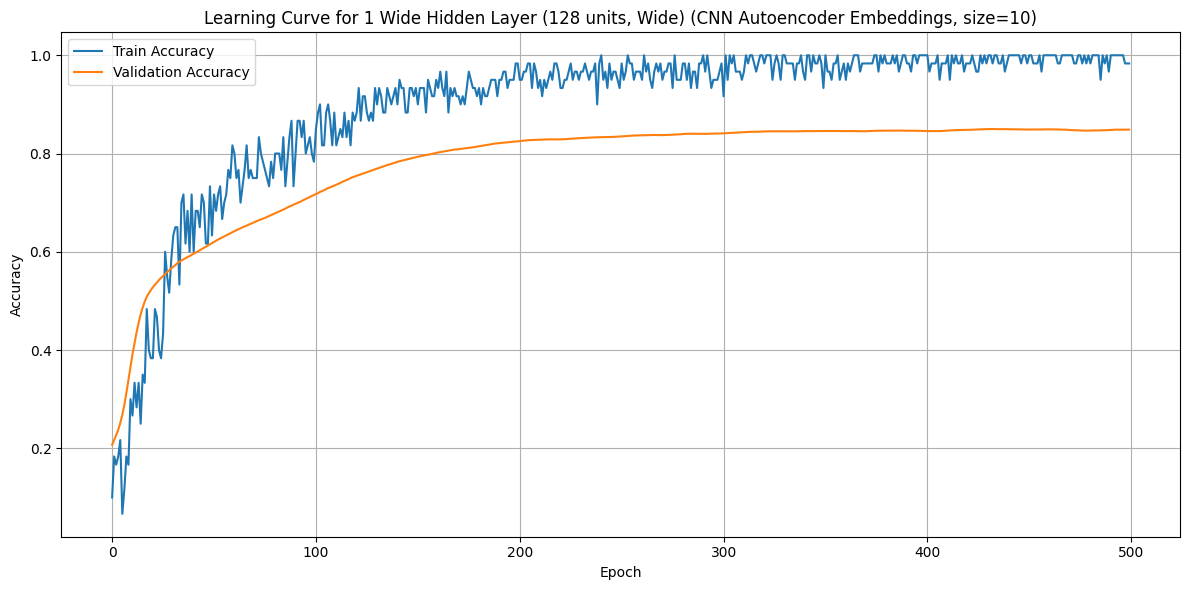

In [ ]:
# --- Part 3, Final Experiment ---

# Get the trained encoder from the convolutional autoencoder from last experiment
dense_deep_encoder = autoencoder_models["Deeper Dense"].get_layer(index=0)

# Generate embeddings for training set using embedding size 10
dense_deep_train_embeddings = dense_deep_encoder.predict(train_images, verbose=0)

# Define only the 128-units classifier architecture
classifier_architectures = [
    (
        "1 Wide Hidden Layer (128 units, Wide)",
        keras.Sequential([
            layers.Input(shape=(embedding_size_p3,)),
            layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
            layers.Dropout(0.5),
            layers.Dense(10, activation='softmax')
        ])
    )
]

part3_final_results = {}

for clf_name, clf_model in classifier_architectures:
    clf_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = clf_model.fit(
        dense_deep_train_embeddings, train_labels,
        epochs=500,
        batch_size=100,
        validation_split=0.999,
        verbose=1
    )
    final_val_acc = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    part3_final_results[clf_name] = {
        "history": history.history,
        "final_val_acc": final_val_acc,
        "final_val_loss": final_val_loss
    }
    print(f"Final Validation Accuracy for '{clf_name}': {final_val_acc:.4f}, Final Validation Loss: {final_val_loss:.5f}")

    # Plot learning curve
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"Learning Curve for {clf_name} (CNN Autoencoder Embeddings, size=10)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()